In [32]:
# Imports
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors


In [33]:
ds = xr.open_dataset('MergedIncident')
ds = ds.sortby('valid_time')

ds

sh: 1: getfattr: not found


<xarray.Dataset> Size: 3GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-10 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    u10                (valid_time, y, x) float32 373MB ...
    v10                (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    d2m                (valid_time, y, x) float32 373MB ...
    cape               (valid_time, y, x) float32 373MB ...
    cin                (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-01T15:45 GRIB to CDM+CF via cfgrib-0.9.1...

In [34]:
# Choose one time index (you can change this later)
fcst = ds.isel(valid_time=48) 


# Extract initialization and valid times
init_time = pd.to_datetime(ds.time.values)
valid_time = pd.to_datetime(fcst.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y') #for t in valid_time]

print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Oct 10 2021
Valid Time: 00Z Oct 12 2021


In [35]:
u10 = fcst['u10']
v10 = fcst['v10']

wind_speed = np.sqrt(u10**2 + v10**2)

In [36]:
# CONUS Map Function
def conus_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)

    return fig, ax

In [37]:
import metpy.calc as mpcalc
from metpy.calc import lat_lon_grid_deltas
import metpy.units as units
import numpy as np

# Convert temperatures to Fahrenheit
temp_f = (fcst['t2m'] - 273.15) * 9/5 + 32
dewpt_f = (fcst['d2m'] - 273.15) * 9/5 + 32

cape = fcst['cape']
cin = fcst['cin']
cloud = fcst['tcc'] * 100

# Compute dx and dy from lat/lon
dx, dy = lat_lon_grid_deltas(fcst['longitude'].values, fcst['latitude'].values)

# Compute convergence (negative divergence)
convergence = -mpcalc.divergence(fcst['u10'], fcst['v10'], dx=dx, dy=dy)

def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):

    # Temperature (best 60–90°F)
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)

    # Dewpoint (logistic growth)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))

    # CAPE (exponential growth)
    cape_index = 100 * (1 - np.exp(-cape / 1000))

    # CIN (inverse exponential decay)
    cin_index = 100 * np.exp(-np.abs(cin) / 100)

    # Cloud cover (logistic)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))

    # Convergence (scaled)
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

    # Weighted Index Calculation
    index = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.3 * cape_index + 0.2 * cin_index + 0.05 * cloud_cover) # I CHANGED THE INDEX TO TEST 

    return index

# Printed out index maximum and minimum values
index = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)

/tmp/ipykernel_355762/2198280180.py:18: UserWarning: More than one time coordinate present for variable  "u10".
  convergence = -mpcalc.divergence(fcst['u10'], fcst['v10'], dx=dx, dy=dy)


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Text(1.0, 1.0, 'Valid: 0')

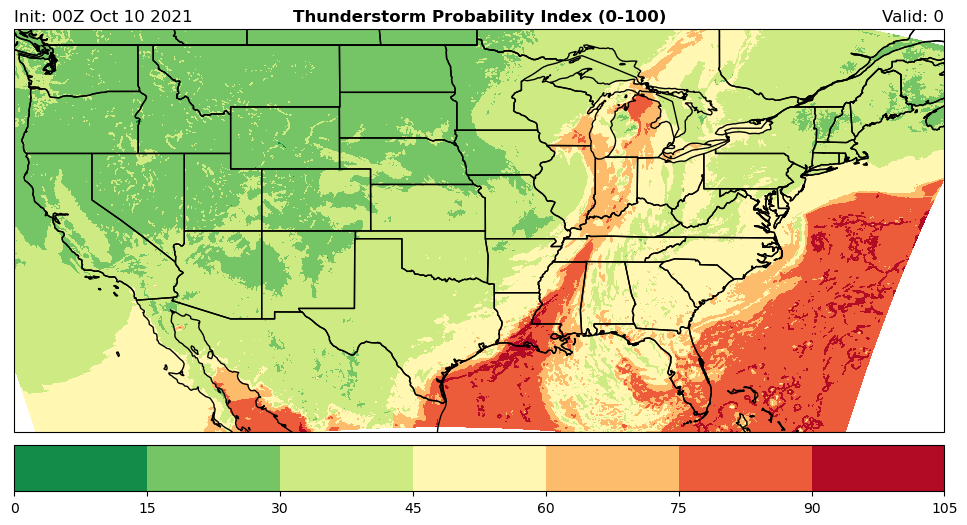

In [38]:
fig, ax = conus_map()

# Plot with colormap + colorbar
c = ax.contourf(
    fcst['longitude'], 
    fcst['latitude'], 
    index,
    cmap='RdYlGn_r',          
    shading='auto',
    vmin=0, vmax=100        
)


cb = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.02)
plt.title("Thunderstorm Probability Index (0-100)", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str[1]}", loc='right')



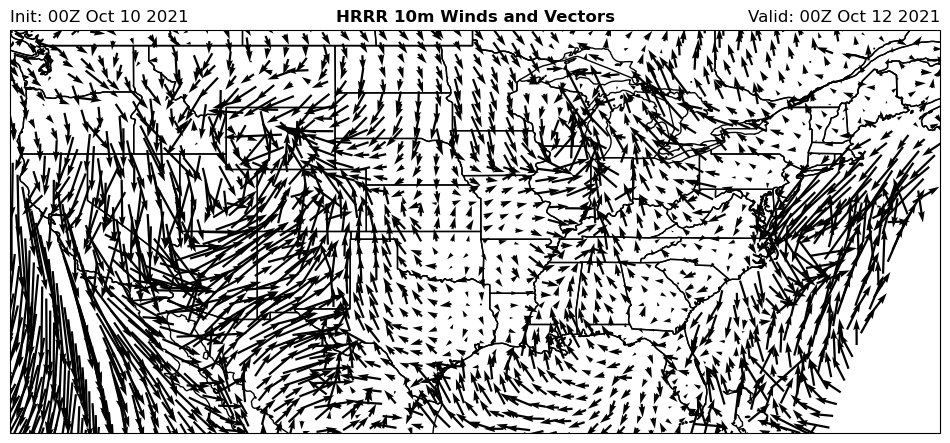

In [39]:
fig, ax = conus_map()

skip = 30

ax.quiver(ds.longitude[::skip, ::skip],
          ds.latitude[::skip, ::skip],
          u10[::skip, ::skip],
          v10[::skip, ::skip],
          transform=ccrs.PlateCarree(),
          scale=200)

plt.title("HRRR 10m Winds and Vectors", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

plt.show()

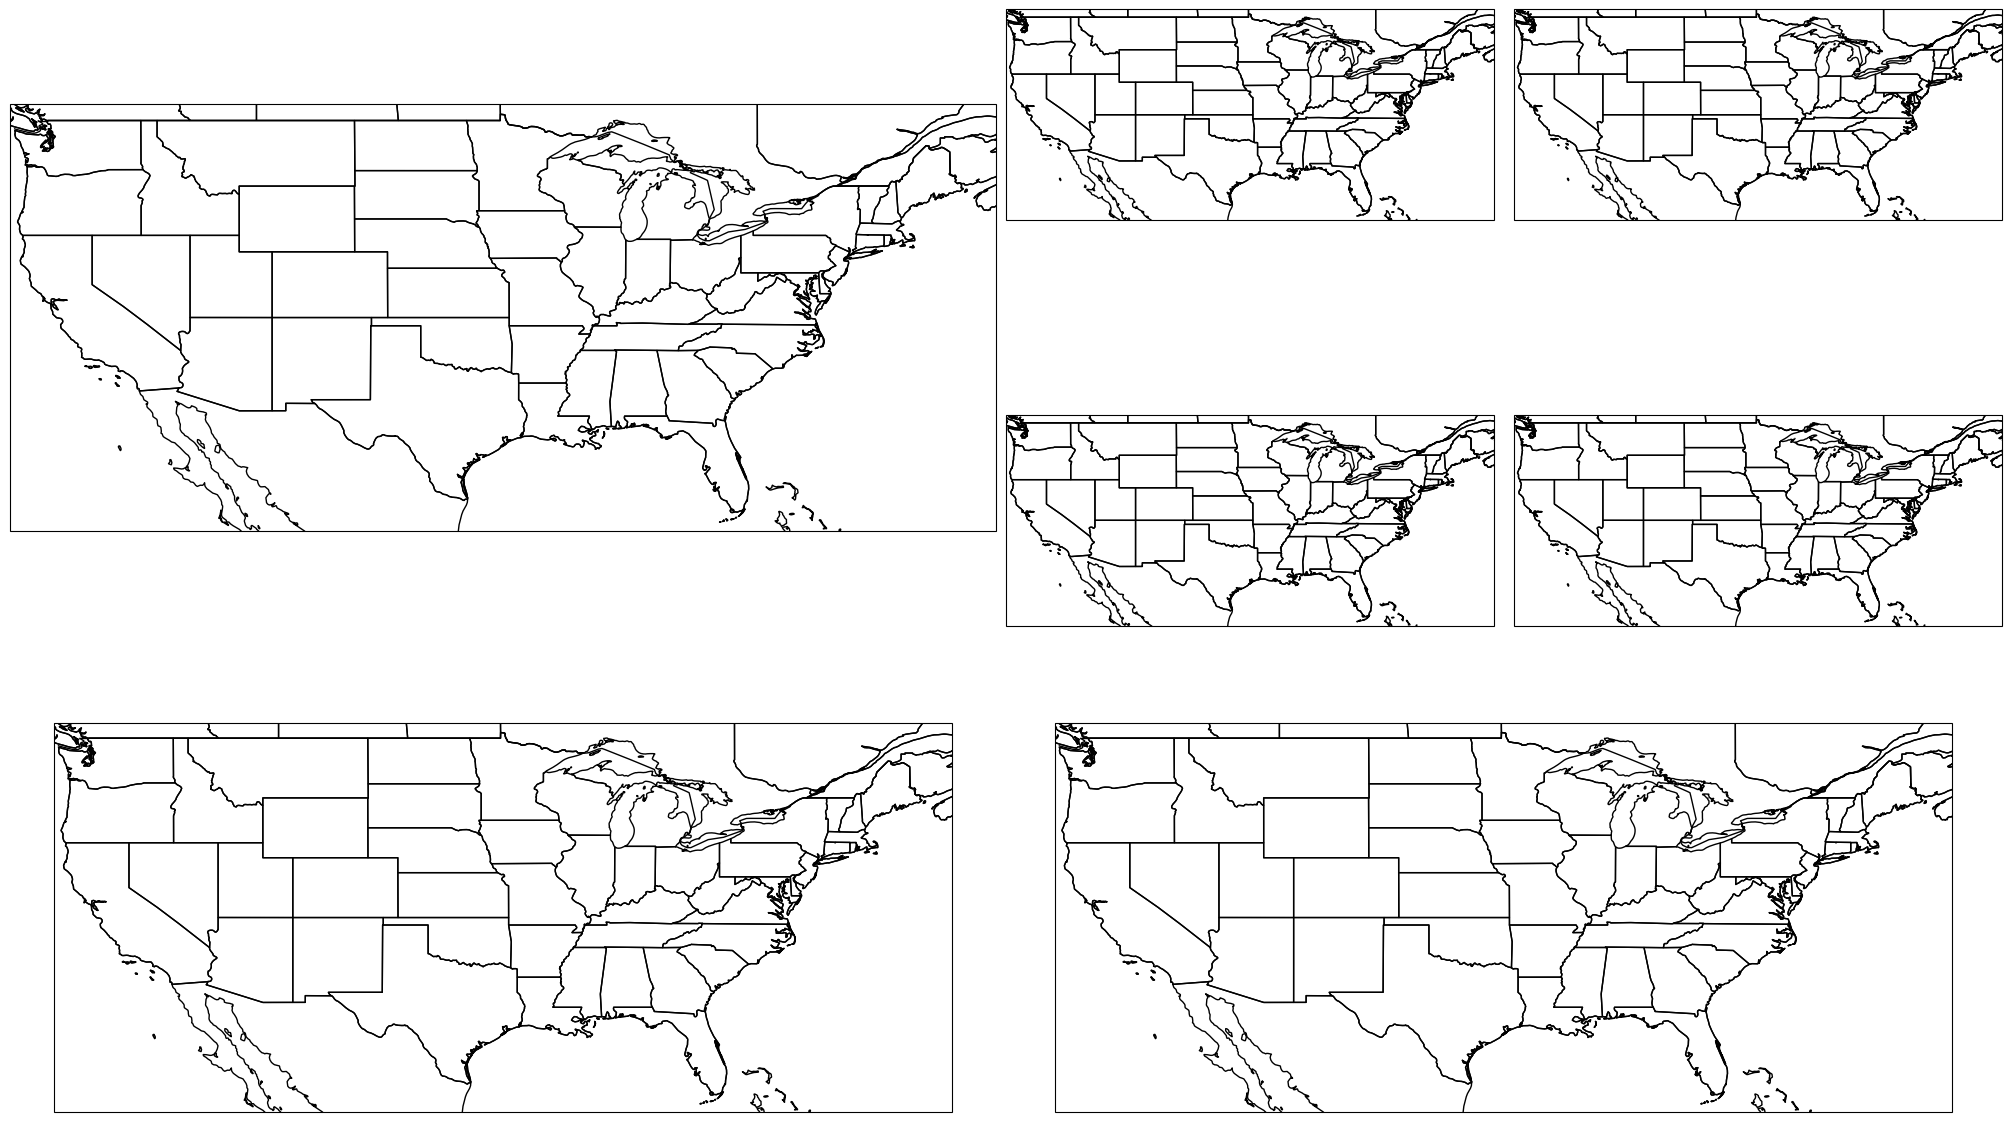

In [59]:
def make_conus_ax(ax):

    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return ax

#set bounds for index map
bounds = np.linspace(0, 100, 101)

# Use BoundaryNorm to force exact colorbar edges
norm = mcolors.BoundaryNorm(bounds, ncolors=256)

def make_layout():
    fig, axes = plt.subplot_mosaic(
        [
            ["main", "main", "ax1", "ax2"],
            ["main", "main", "ax3", "ax4"],
            ["ax5",  "ax5",  "ax6", "ax6"],
        ],
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(20, 12),
        layout="constrained"
    )

    ax_main = axes["main"]
    ax1 = axes["ax1"]
    ax2 = axes["ax2"]
    ax3 = axes["ax3"]
    ax4 = axes["ax4"]
    ax5 = axes["ax5"]
    ax6 = axes["ax6"]

    for ax in [ax_main, ax1, ax2, ax3, ax4, ax5, ax6]:
        make_conus_ax(ax)
        
    return (fig, axes["main"],axes["ax1"], axes["ax2"],axes["ax3"], axes["ax4"],axes["ax5"], axes["ax6"])


fig, ax_main, ax1, ax2, ax3, ax4, ax5, ax6 = make_layout()


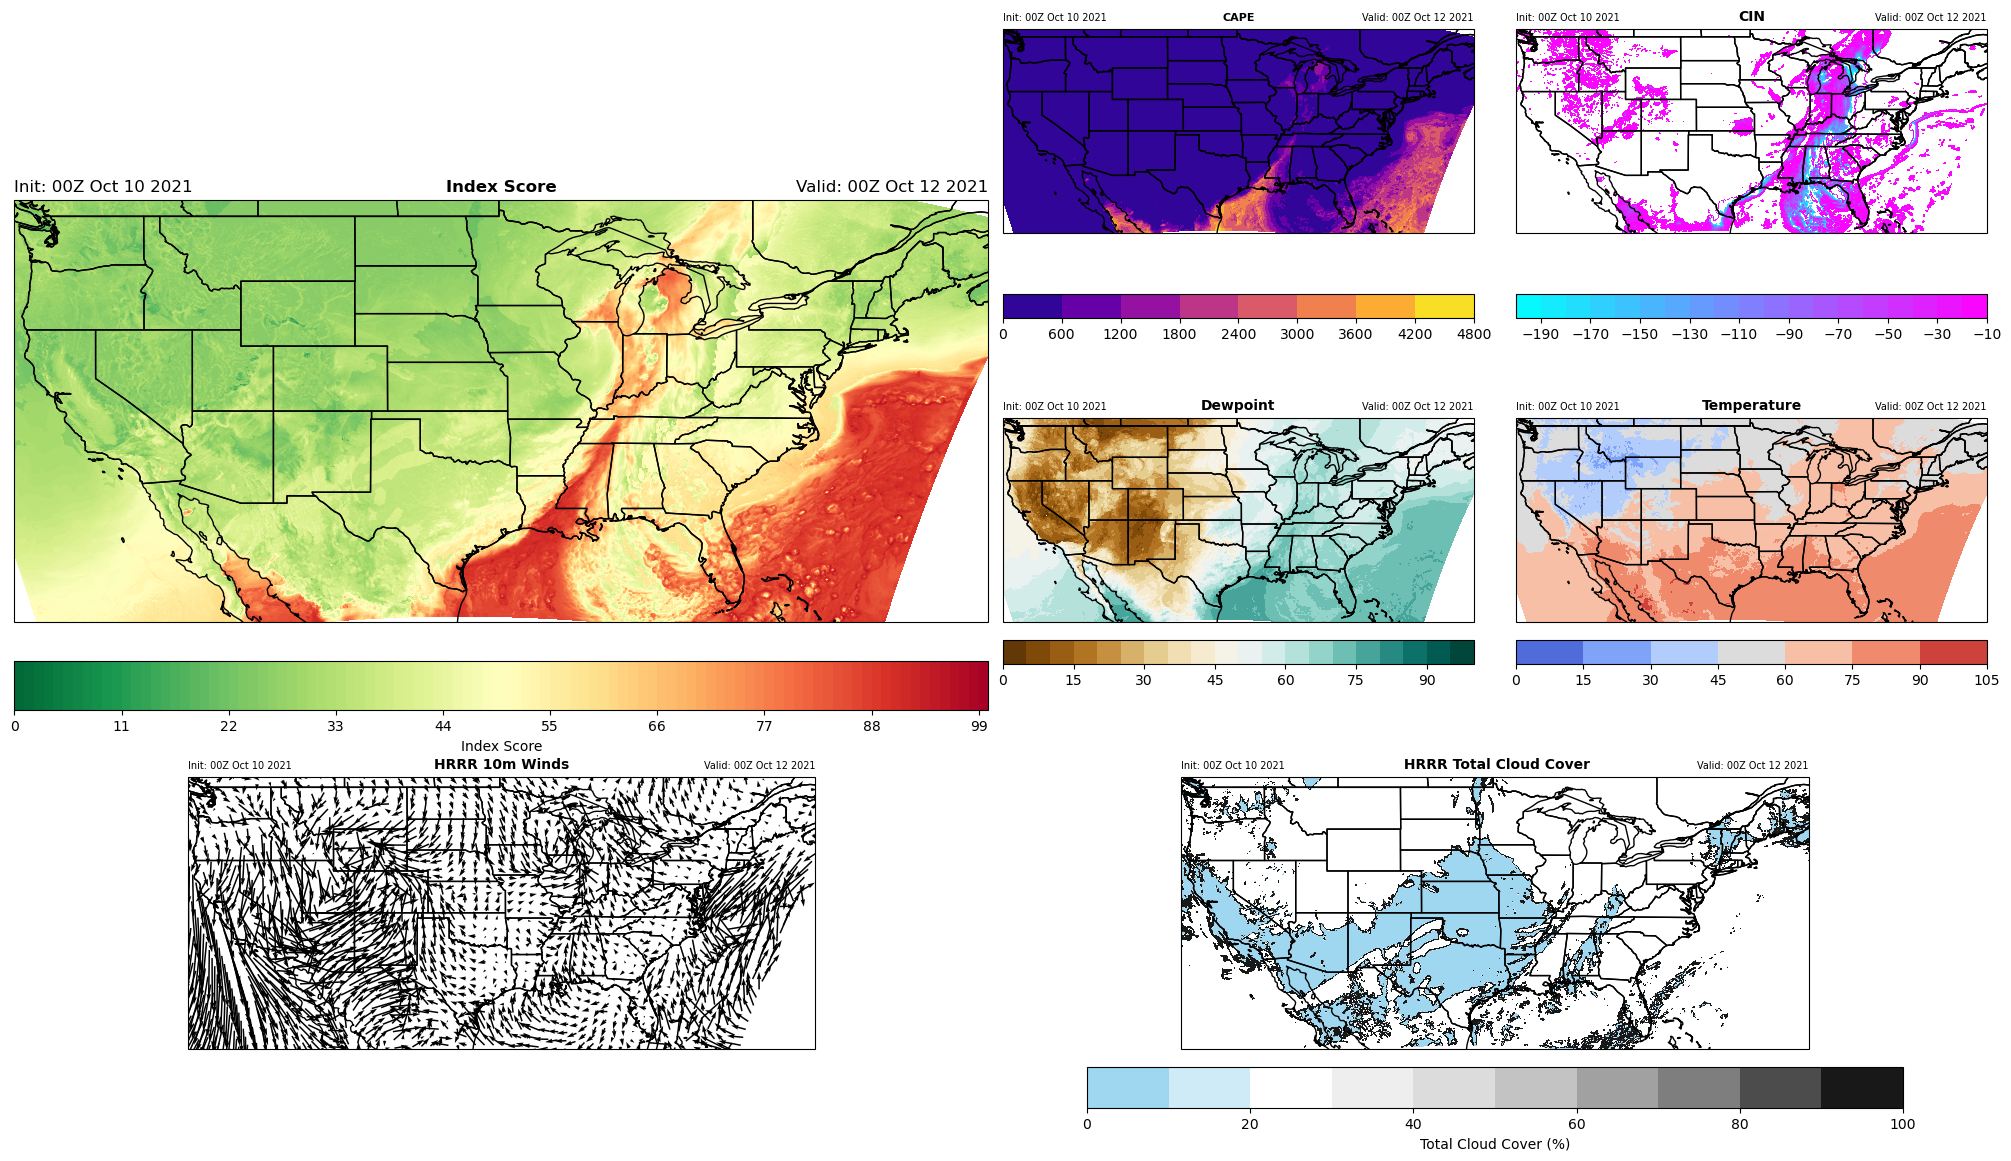

In [60]:
fig, ax_main, ax1, ax2, ax3, ax4, ax5, ax6 = make_layout()

#--- Big Map (Index) ---
cf = ax_main.contourf(ds.longitude, ds.latitude, index, levels=bounds,
                      cmap='RdYlGn_r',
                      transform=ccrs.PlateCarree())
cbar = plt.colorbar(cf, ax=ax_main, orientation='horizontal', pad=0.05)
cbar.set_label('Index Score')
ax_main.set_title("Index Score", loc='center', fontweight='bold')
ax_main.set_title(f"Init: {init_str}",   loc='left')
ax_main.set_title(f"Valid: {valid_str}", loc='right')

# --- Map 1 (Top Right) ---
cape = fcst['cape']
cf1 = ax1.contourf(ds.longitude, ds.latitude, cape,
                   transform=ccrs.PlateCarree(), cmap='plasma')
plt.colorbar(cf1, ax=ax1, orientation='horizontal', pad=0.01)
ax1.set_title("CAPE", loc='center', fontweight='bold', fontsize=8)
ax1.set_title(f"Init: {init_str}",   loc='left', fontsize=7)
ax1.set_title(f"Valid: {valid_str}", loc='right', fontsize=7)


# --- Map 2 ---

cin = fcst['cin']
cf2 = ax2.contourf(ds.longitude, ds.latitude, cin, levels = np.arange(-200, 0, 10),
                   transform=ccrs.PlateCarree(), cmap='cool')
plt.colorbar(cf2, ax=ax2, orientation='horizontal', pad=0.01)
ax2.set_title("CIN", loc='center', fontweight='bold', fontsize=10)
ax2.set_title(f"Init: {init_str}",   loc='left', fontsize=7)
ax2.set_title(f"Valid: {valid_str}", loc='right', fontsize=7)

# --- Map 3 ---
dew = (fcst['d2m'] - 273.15) * 9/5 + 32
cf3 = ax3.contourf(ds.longitude, ds.latitude, dew, levels = np.arange(0, 105, 5),
                   transform=ccrs.PlateCarree(), cmap='BrBG')
plt.colorbar(cf3, ax=ax3, orientation='horizontal', pad=0.05)
ax3.set_title("Dewpoint", loc='center', fontweight='bold', fontsize=10)
ax3.set_title(f"Init: {init_str}",   loc='left', fontsize=7)
ax3.set_title(f"Valid: {valid_str}", loc='right', fontsize=7)

# --- Map 4 ---
temp = (fcst['t2m'] - 273.15) * 9/5 + 32
cf4 = ax4.contourf(ds.longitude, ds.latitude, temp,
                   transform=ccrs.PlateCarree(), cmap='coolwarm')
plt.colorbar(cf4, ax=ax4, orientation='horizontal', pad=0.05)
ax4.set_title("Temperature", loc='center', fontweight='bold', fontsize=10)
ax4.set_title(f"Init: {init_str}",   loc='left', fontsize=7)
ax4.set_title(f"Valid: {valid_str}", loc='right', fontsize=7)


# --- Map 5 (Bottom Right) ---

cf5 = ax5.quiver(ds.longitude[::skip, ::skip],
          ds.latitude[::skip, ::skip],
          u10[::skip, ::skip],
          v10[::skip, ::skip],
          transform=ccrs.PlateCarree(),
          scale=200)

ax5.set_title("HRRR 10m Winds", loc='center', fontweight='bold', fontsize=10)
ax5.set_title(f"Init: {init_str}", loc='left', fontsize=7)
ax5.set_title(f"Valid: {valid_str}", loc='right', fontsize=7)

# --- Map 6 ---

cloud_colors = ['skyblue', 'white', 'lightgray', 'gray', 'black']
cloud_cmap = LinearSegmentedColormap.from_list('clouds', cloud_colors)

cloud = fcst['tcc'] * 100  # convert to %

cf6 = ax6.contourf(ds.longitude, ds.latitude, cloud,
                 levels=np.arange(0, 101, 10),
                 cmap=cloud_cmap,
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf6, ax=ax6, orientation='horizontal', pad=0.05)
cbar.set_label('Total Cloud Cover (%)')

ax6.set_title(" HRRR Total Cloud Cover", loc='center', fontweight='bold', fontsize=10)
ax6.set_title(f"Init: {init_str}", loc='left', fontsize=7)
ax6.set_title(f"Valid: {valid_str}", loc='right', fontsize=7)

plt.show()







